In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gc
import itertools

In [2]:
%%bash
ls "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"

001_010
011_020
021_030
031_040
041_050
051_060
061_070
071_080
081_090
091_100


In [3]:
base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"
path = base_path + "/".join(["/", which_chunk[0], which_file])
file = uproot.open(path)

In [4]:
names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
names_track      = file.keys(filter_name=r"*O2filtertrack")
names_coll       = file.keys(filter_name=r"*O2collision_001")

names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)
   
    z1_track = pz1/px1 * x_SV + row1["fZ"]
    z2_track = pz2/px2 * x_SV + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

In [6]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

In [7]:
list_of_df = []               # add the dataframes in a list (we will concat them later)
for i in range (len(names_coll)):
    # Read collision tree
    df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame

    # # Read track and trackextr using boolean mask for track and trackextr:
    df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
         "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka", "fNsigmaTOFpr"], library="pd" )
    df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")

    # take the corresponding data of MC
    df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                  "fMainBeautyAncestorPdgCode"],library="pd")
    df_track = pd.merge(left=df_track, 
                         right=df_track_mc, 
                         how='inner', left_index=True, right_index=True)

    # merge all rows
    df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)

    # keep all particles that come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0
    df_trackextr = df_trackextr[(df_trackextr["fMainHfMotherPdgCode"]  == 421) & (df_trackextr["fPdgCode"].isin([-321,211])) &
        (df_trackextr["fMainBeautyAncestorPdgCode"]==0)]

    # keep only those with 2 or more daughter
    df_trackextr = df_trackextr[df_trackextr["fMainMotherNfinalStateDaught"] >= 2]

    mask = df_trackextr.eval(cut_expression)        # create boolean mask
    # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
    df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
                                           "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

    # we cut rows where the fIndexCollision is negative (for some reason) >>>>>TODO<<<<<<
    valid = df_trackextr["fIndexCollisions"] >= 0        
    df_trackextr = df_trackextr[valid].reset_index(drop=True)  

    
    # Now we for correct fPosZ (and add that column)
    df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
  
    df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values

    df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values

    df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
    df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index 

    # save results:
    # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
    # if  i==0: df = df_trackextr
    # else: df = pd.concat([df, df_trackextr], ignore_index=True)
    # # ALTERNATIVE 2:
    list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
    
    # Update offset for next loop
    collision_offset += len(df_coll)

# # UNCOMMENT FOR ALTERNATIVE 2:
df = pd.concat(list_of_df, ignore_index=True)

# Merge everything in the total dataframe
N = len(df)

# moment columns:
df["px"] = df["fPt"] * np.cos(df["fAlpha"])
df["py"] = df["fPt"] * np.sin(df["fAlpha"])
df["pz"] = df["fPt"] * np.sinh(df["fEta"])

# energy column (differentiating pions and kaons):
mass = np.where(df["fPdgCode"] == +211, m_pi, m_K)
df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)

# Debug
print("The starting dataframe has", len(df), "rows and ", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The starting dataframe occupies {memory:.2f} MB")
# df.head()

# ALTERNATIVE 3:
# let's initialize some lists, then we will create a dataframe
collision_indices = []
track1_indices = []
track2_indices = []
dcaXY_products = []
inv_masses = []
inv_masses_approx = []
pt_totals = []
pz_totals = []
SV_X = []
SV_Y = []
SV_Z = []
decay_lengths = []
cos_pointings = []

counting=0 # debug variable

# let's divide the dataframe for positive and negative charged
df_pos = df[ df['fCharge']>0 ]
df_neg = df[ df['fCharge']<0 ]

# Iterate over each collision group
for collision_idx in (df_neg['fIndexCollisions'].unique()):
    group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
    group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]

    # Only collisions with at least a pair
    if len(group_pos) < 1:   continue

    # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
    group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
    group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})

    # let's crate indexes for all possible pairs:
    combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )

    # Iterate over all unique pairs of tracks
    for combo in combinat:
        row_neg = group_neg.iloc[combo[0]]
        row_pos = group_pos.iloc[combo[1]]

        product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
        
        # INVARIANT MASS calculation
        pt1, pt2 = row_neg['fPt'], row_pos['fPt']
        # eta1, eta2 = row_neg['fEta'], row_pos['fEta']
        # phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
        # delta_eta = eta1 - eta2
        # delta_phi = phi1 - phi2

        # approximation formula
        # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))

        # exact formula:
        E1 = row_neg['Ene']
        E2 = row_pos['Ene']
        px1 = row_neg["px"]
        py1 = row_neg["py"]
        pz1 = row_neg["pz"]
        px2 = row_pos["px"]
        py2 = row_pos["py"]
        pz2 = row_pos["pz"]
        inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )


        # total transverse momentum of the D0 candidate (used later for sliced plots)
        pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)

        # secondary vertex
        SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
        # SV_X.append(SV_coords[0])
        # SV_Y.append(SV_coords[1])
        # SV_Z.append(SV_coords[2])

        # decay length: distance between PV and SV
        PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
        decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )

        # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
        mother_direction = [px1+px2, py1+py2, pz1+pz2]
        flight_line = SV_coords - PV_coords
        cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
        
        # let's add the found pairs to the lists
        collision_indices.append(int(row_neg['fIndexCollisions']))
        # track1_indices.append(int(row_neg['orig_index']))
        # track2_indices.append(int(row_pos['orig_index']))
        dcaXY_products.append(product_dcaXY)
        inv_masses.append(inv_mass)
        # inv_masses_approx.append(inv_mass_approx)
        pt_totals.append(pt_total)
        pz_totals.append(pz1+pz2)

    # # let's free the memory RAM of unused dataframes:
    # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # del group
    # gc.collect()

    # debug:
    counting += 1
    if counting % 50000 ==0: print(counting, end=' ')


# create a dataframe with the result:
df_pairs = pd.DataFrame({
    'collision_index': collision_indices,
    # 'track1_index': track1_indices,
    # 'track2_index': track2_indices,
    'dcaXY_product': dcaXY_products,
    'inv_mass': inv_masses,
    # 'inv_mass_approx': inv_masses_approx,
    'pt': pt_totals,
    'pz': pz_totals,
    # 'X_SV': SV_X,
    # 'Y_SV': SV_Y,
    # 'Z_SV': SV_Z,
    'decay_length': decay_lengths,
    'cos_pointing': cos_pointings
})
df_pairs

The starting dataframe has 7040 rows and  17 columns.
The starting dataframe occupies 0.48 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing
0,918,-3.059293e-04,1.837824,4.648007,1.279787,4.812736,-0.235473
1,921,-3.965073e-06,1.841457,3.045008,0.461630,0.008191,0.823952
2,1032,1.392615e-05,1.870741,0.271051,-0.563369,7.890414,-0.895699
3,1169,4.618064e-07,1.846030,3.869652,1.815894,0.007072,-0.451707
4,1200,-7.545209e-06,1.878515,0.521350,-0.571413,0.048008,0.668387
...,...,...,...,...,...,...,...
928,218498,2.027699e-06,1.857876,0.612198,1.093280,0.009517,-0.257318
929,218652,-6.627962e-05,1.868814,3.305967,0.058500,0.033754,0.728713
930,218658,-1.593049e-04,1.889495,3.111890,-1.520200,0.291117,0.521431
931,218789,-7.101874e-06,1.886911,10.253227,-1.226341,0.061298,0.950502


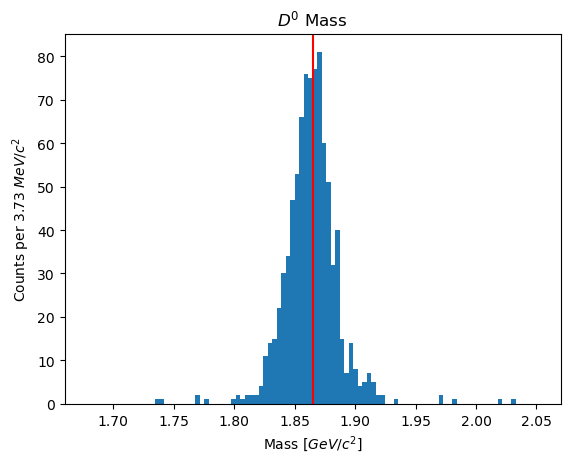

In [28]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(df_pairs["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass")
plt.savefig("D0_Mass_MC.png")
plt.show()